## Exploratory Data Analysis

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_parquet('../data/processed/nyc_taxi_clean.parquet')

In [3]:
# Display column names of the dataframe
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'Pickup_Date',
 'Pickup_Hour']

## Temporal Analysis:


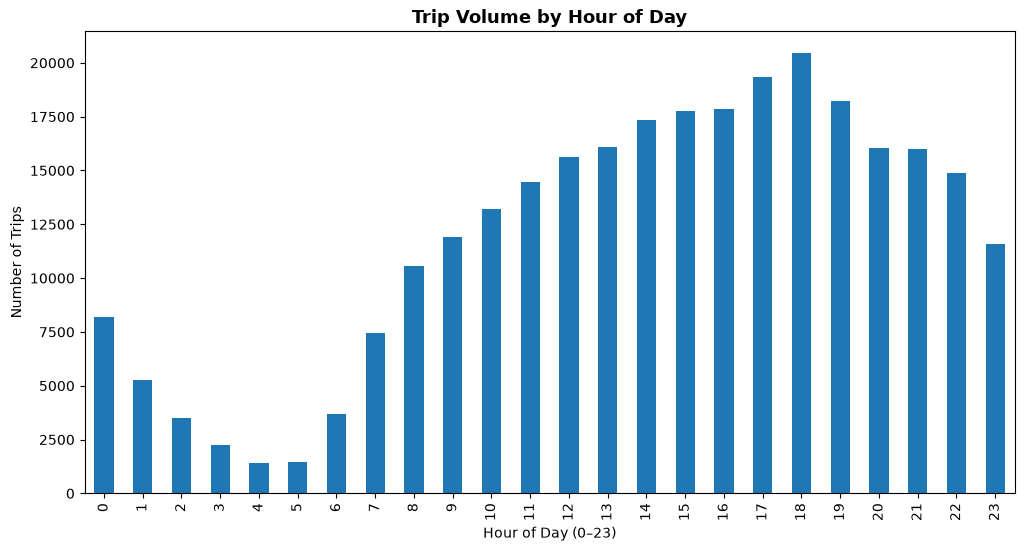

In [4]:
# Hourly trip volume analysis
plt.figure(figsize=(12,6))
df['Pickup_Hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Trip Volume by Hour of Day", fontsize=13, fontweight='bold')
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Trips")
plt.show()

**Note on numbers:** Trip counts reflect a 5% time-stratified 
sample. Absolute counts can be scaled by 20x for population 
estimates. Relative patterns and proportions are fully preserved.


**Insights:**

- Trip demand follows a single peak distribution rising steadily from a low of ~1500 trips at 4-5 am to a peak of ~20000 at 5-6 pm. 

- The evening peak accounts for a large share od daily trips driven by end of the day commuters returning home and evening social trips.

- Fleet Operators should maximise availability during 3 pm - 8 pm,scheduling maintenance, breajs, shift changes outside this window. 

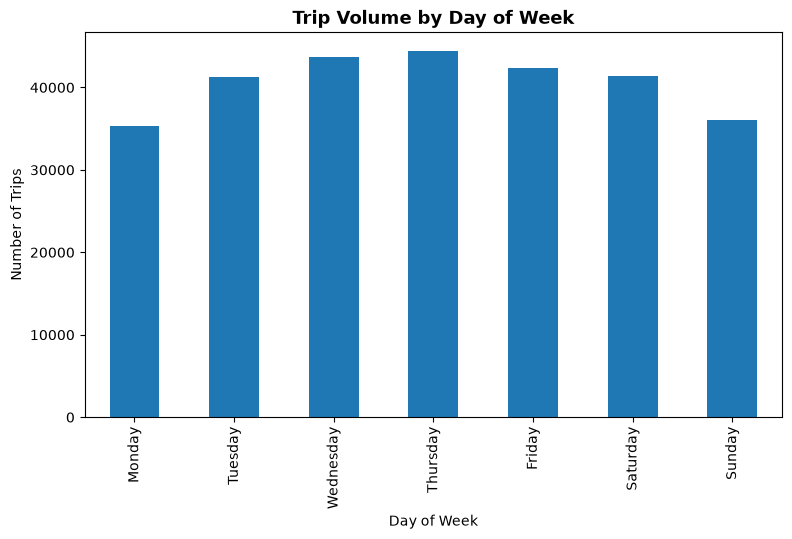

In [5]:
# Daily trip volume analysis
df['Weekday'] = df['tpep_pickup_datetime'].dt.day_name()
plt.figure(figsize=(9,5))
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df['Weekday'].value_counts().reindex(order).plot(kind='bar')
plt.title("Trip Volume by Day of Week", fontsize=13, fontweight='bold')
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.show()

**Insights:**
- Weekdays outperform weekends consistently with wednesday and thursday showing the highest trip volumes.This says that the NYC Yellow Taxis are primarily commuter and business travel service.

- Driver scheduling should weight Tuesday through Thursday heavily.Sunday represents the lowest revenue oppurtunity and is optimal for vehicle maintenance and driver rest days 

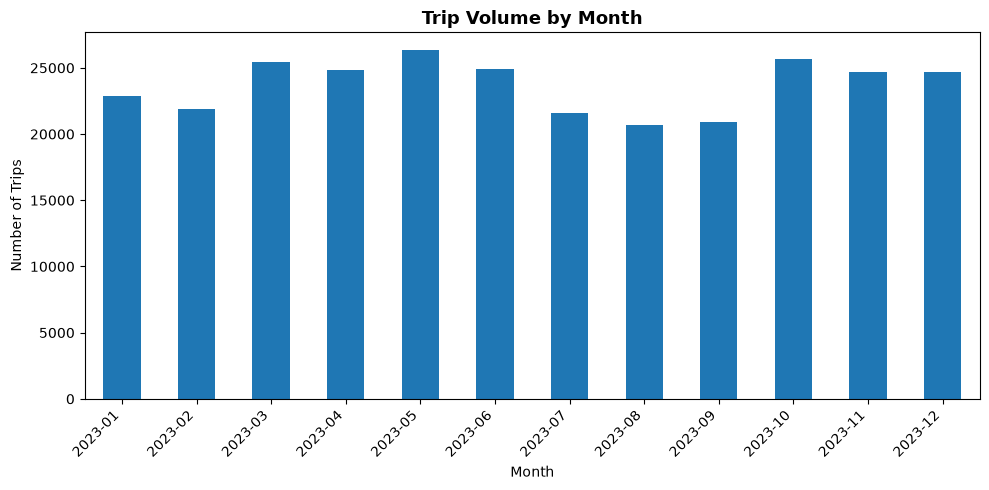

In [6]:
# Trip volume by month 
df['Month'] = df['tpep_pickup_datetime'].dt.strftime('%Y-%m')

plt.figure(figsize=(10, 5))
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Trip Volume by Month", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
- The volume shows a strong seasonal swing(~24%) with March-June and October-December being the busiest months.

- The dip from June to September is consistent with the summer festivals and exodus patterns.October shows a strong recovery aligning with busy fall season. 

- January and February also show relatively lower volumes alongside the June–September dip, creating a dualtrough pattern across the year. Winter cold suppresses travel and outdoor activity resulting lower volume of trips.

- Fleet operators should plan for slightly lower revenue in June-September and align driver recruitment, vehicle servicing, and marketing campaigns around the March–June and October-December peaks.

## Financial Analysis:

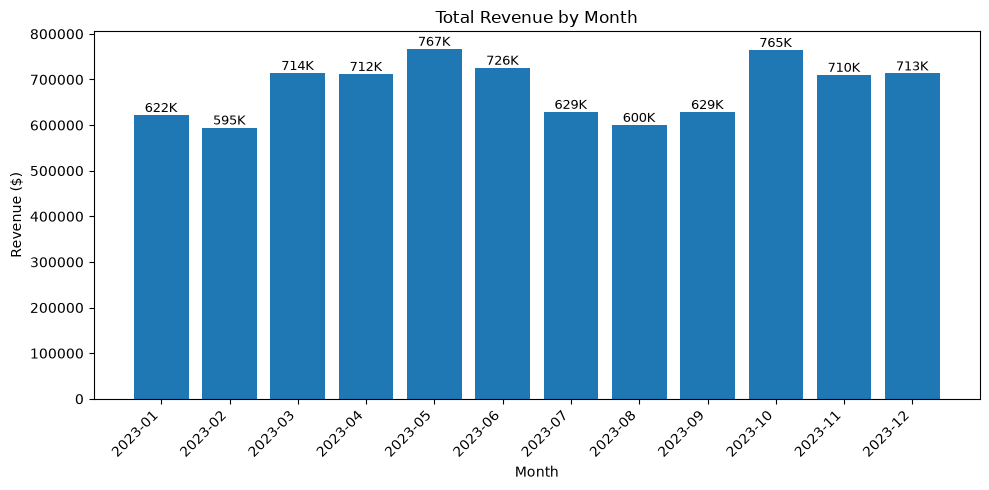

In [7]:

# Total revenue by month
df['MonthNum'] = df['tpep_pickup_datetime'].dt.month

revenue = df.groupby('Month')['total_amount'].sum().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(revenue.index, revenue.values)
plt.xticks(rotation=45, ha='right')
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

for b, v in zip(bars, revenue.values):
    lbl = f"{v/1_000_000:.1f}M" if v >= 1_000_000 else f"{v/1000:.0f}K"
    plt.text(b.get_x() + b.get_width()/2, v, lbl,
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Insights:**
- Revenue pattern closely mirrors trip volume which means that trip frequency is the primary driver of Monthly Revenue.

- May and October are the busiest months at ~767K and ~765K respectively in the sample (~$15.3M each at scale).

- February is the single lowest revenue month at ~595K (~$11.9M at scale) compounded by both winter suppression of demand and the shortest calendar month.



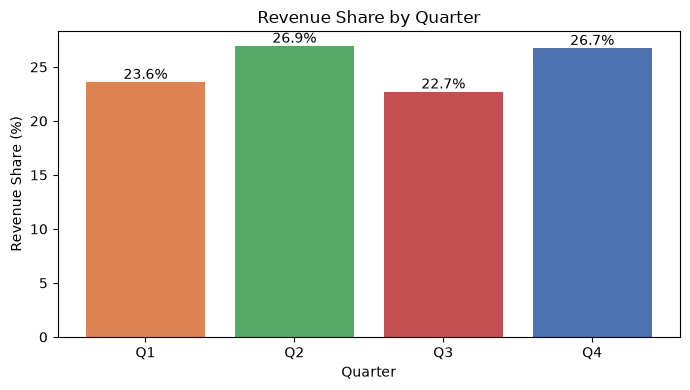

In [8]:
# Revenue Share by Quarter
df['Quarter'] = df['tpep_pickup_datetime'].dt.quarter

quarter_revenue = df.groupby('Quarter')['total_amount'].sum()
prop = (quarter_revenue / quarter_revenue.sum()) * 100

plt.figure(figsize=(7, 4))
plt.bar([f"Q{q}" for q in prop.index], prop.values, 
        color=['#DD8452', '#55A868', '#C44E52', '#4C72B0'])
plt.title("Revenue Share by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Revenue Share (%)")
for i, v in enumerate(prop.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Insights:**
- Revenue is evenly distributed across all four quarters, ranging narrowly between 22.7% (Q3) and 26.9% (Q2),a spread of just 4.2 percentage points.This confirms demand is structurally stable year-round with no single quarter dominating revenue.

- Q2 and Q4 are the two strongest quarters at 26.9% and 26.7% respectively,together accounting for over 53% of annual revenue.Q3 is the weakest quarter at 22.7%, consistent 
  with the summer exodus pattern identified in the monthly analysis. 

- Fleet Operators should focus on consistent year-round operations and cost management more than seasonal surge planning as they cannot rely on a single strong quarter to 
  compensate for weak periods.

### Fare Correlation Analysis:


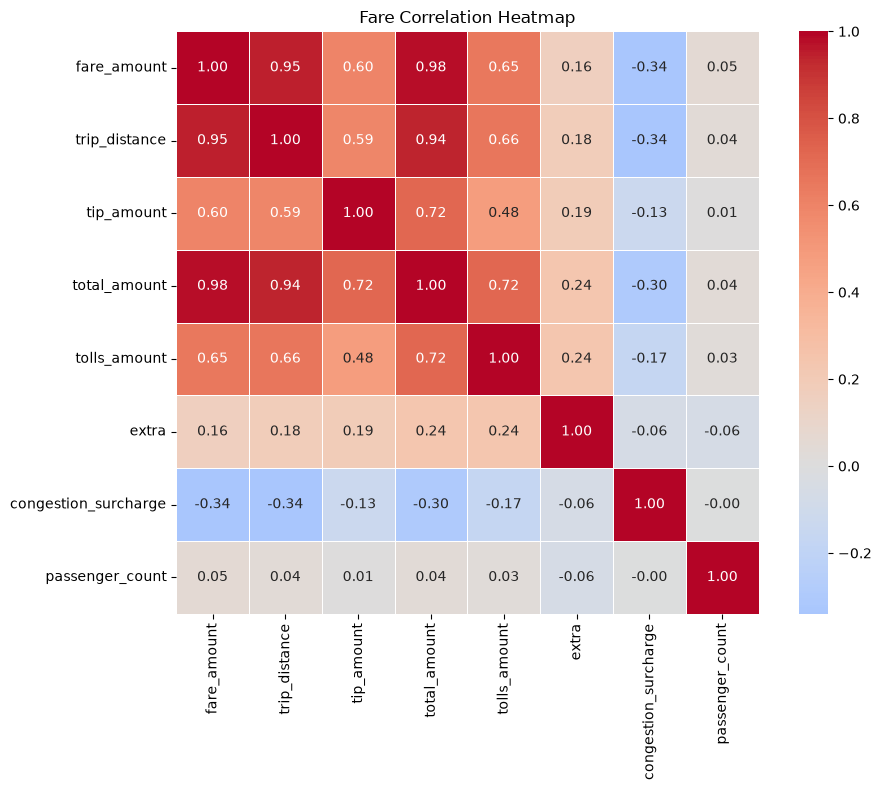

In [9]:
cols = [
    'fare_amount', 'trip_distance', 'tip_amount','total_amount', 'tolls_amount', 'extra','congestion_surcharge', 'passenger_count'
]

corr_matrix = df[cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Fare Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insights:**
- NYC taxi pricing is fundamentally distance driven, making longer trips the primary revenue opportunity for drivers.

- Total amount and tolls both rise naturally with distance.This means airport and outer-borough runs generate revenue on multiple dimensions simultaneously: base fare, tolls, and higher tips.

- Passenger count has virtually zero correlation with any financial variable, the weakest relationship in the entire matrix

- Tip amount shows a meaningful correlation with both fare (0.60) and distance (0.59).Passengers tip more on longer, more expensive trips.

- Drivers maximising revenue should prioritise longer trips over short hops. Fewer trips at greater distance generates more revenue than high trip volume at low distance.


The heatmap reveals the relationships but fare vs distance, fare vs duration and tip vs total amount
correlations are worth examining more closely to understand 
the shape of the relationship

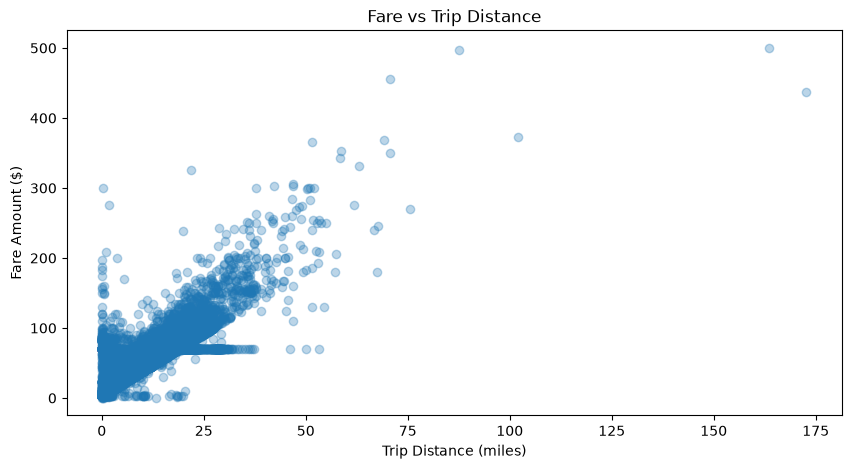

In [10]:
# Show how trip fare is affected by distance

plt.figure(figsize=(10,5))
plt.scatter(df['trip_distance'], df['fare_amount'], alpha=0.3)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare vs Trip Distance")
plt.show()

**Insights:**

- The relationship is strongly linear up to ~25 miles, where 
  the bulk of trips concentrate, beyond that the points become 
  sparse and variance increases significantly, suggesting 
  longer trips involve more variable pricing factors such as 
  waiting time, tolls, and negotiated rates.

- The vertical spread at low distances is 
  notable,fares range from near zero to over $200 for 
  trips under 10 miles, indicating that short trips are 
  the most pricing-inconsistent segment, likely driven by 
  airport flat rates, surge pricing, and toll variations.

Correlation between fare and trip duration: 0.278


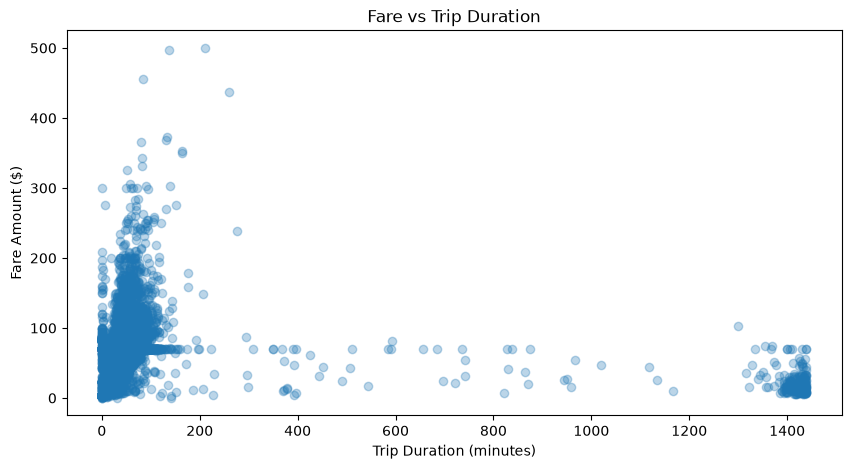

In [11]:
# Calculate trip duration in minutes
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

corr = df['fare_amount'].corr(df['trip_duration'])
print("Correlation between fare and trip duration:", round(corr,3))

plt.figure(figsize=(10,5))
plt.scatter(df['trip_duration'], df['fare_amount'], alpha=0.3)
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare vs Trip Duration")
plt.show()

**Insights:**

- The weak correlation (r=0.278) between fare and duration say that time and distance are decoupled in dense urban conditions. The meter runs on both distance and time, but distance dominates in practice.

- The cluster of trips near 1,400 minutes (~23 hours) 
  represents a known TLC data artefact where meters were 
  not properly reset between shifts.

Correlation between tip and trip distance (credit card only): 0.79


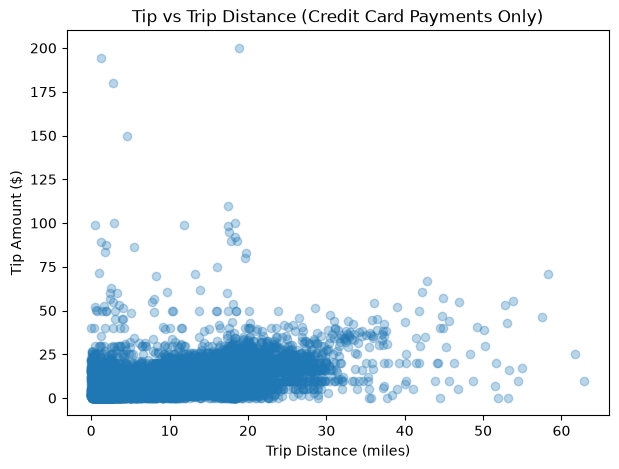

In [12]:
# Filter to credit card payments only (payment_type = 1)
df_tip = df[
    (df['trip_distance'] > 0) & 
    (df['tip_amount'] > 0) & 
    (df['payment_type'] == 1)
]

corr = df_tip['tip_amount'].corr(df_tip['trip_distance'])
print(f"Correlation between tip and trip distance (credit card only): {round(corr, 3)}")

plt.figure(figsize=(7, 5))
plt.scatter(df_tip['trip_distance'], df_tip['tip_amount'], alpha=0.3)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount ($)")
plt.title("Tip vs Trip Distance (Credit Card Payments Only)")
plt.show()

**Insights:**

- Tip amount shows a positive correlation with trip 
  distance (r=0.79), passengers tend to tip more on longer 
  trips.

- The wide vertical spread at short distances (0-25 miles) 
  suggests tipping behaviour on short trips is highly variable 
  and driven by factors beyond distance likely payment method, 
  time of day, and individual passenger generosity.

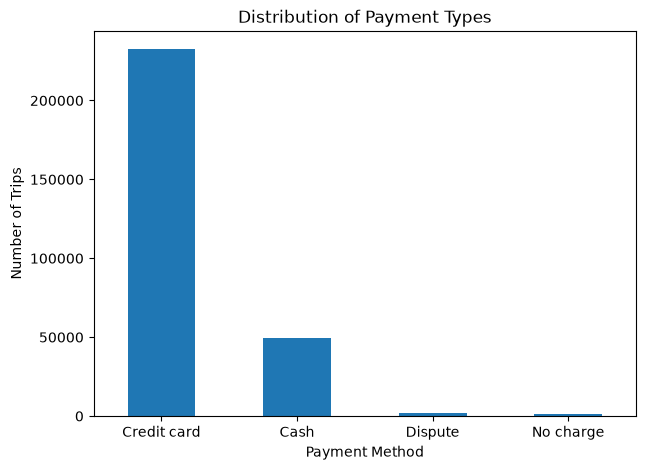

In [13]:
# Analyse the distribution of different payment types.
payment_map = {1:"Credit card", 2:"Cash", 3:"No charge", 4:"Dispute"}

plt.figure(figsize=(7,5))
df['payment_type'].map(payment_map).value_counts().plot(kind='bar')

plt.title("Distribution of Payment Types")
plt.xlabel("Payment Method")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.show()

**Insights:**
- Credit card payments dominates at ~80% of trips versus ~18% cash payments.

### Geographical Analysis

In [14]:
# Import geopandas for spatial analysis
import geopandas as gpd

In [15]:
zones = gpd.read_file('../data/raw/taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [16]:
zones.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    str     
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    str     
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), str(2)
memory usage: 18.5 KB


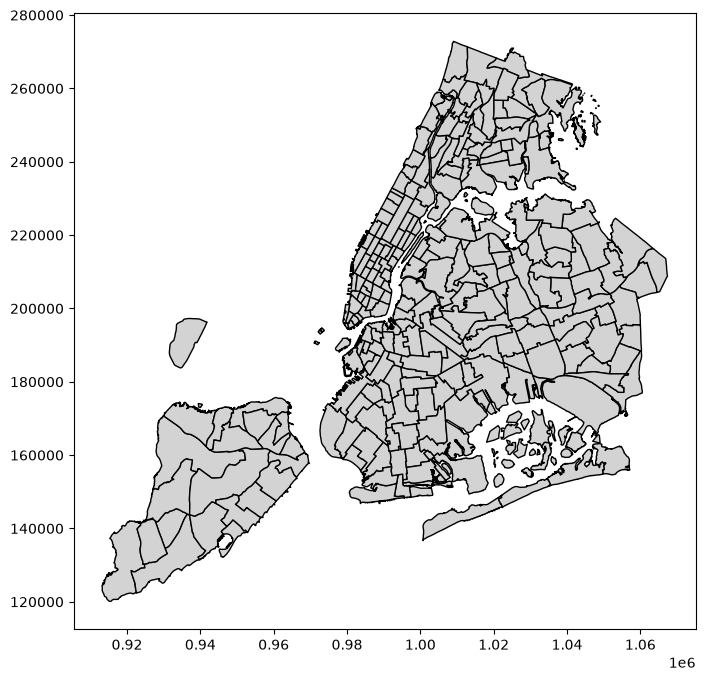

In [17]:
# Plot the taxi zones
zones.plot(figsize=(10,8), color='lightgrey', edgecolor='black');

In [18]:
# Merge zones and trip records using locationID and PULocationID
merged_df = df.merge(zones,left_on='PULocationID',right_on='LocationID',how='left')
print("Merged DataFrame preview:")
merged_df.head()

Merged DataFrame preview:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,MonthNum,Quarter,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-04-24 07:59:14,2023-04-24 08:10:54,2.0,1.68,1.0,N,143,238,1,...,4,2,11.666667,143.0,0.054180,0.000151,Lincoln Square West,143.0,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235..."
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,N,186,170,2,...,1,1,9.216667,186.0,0.024696,0.000037,Penn Station/Madison Sq West,186.0,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21..."
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,N,132,151,1,...,2,1,43.966667,132.0,0.245479,0.002038,JFK Airport,132.0,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283..."
3,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,N,142,237,1,...,9,3,9.266667,142.0,0.038176,0.000076,Lincoln Square East,142.0,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21..."
4,2,2023-11-15 08:41:24,2023-11-15 09:01:54,1.0,2.24,1.0,N,236,161,1,...,11,4,20.500000,236.0,0.044252,0.000103,Upper East Side North,236.0,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220..."


In [19]:
# Group data by location and calculate the number of trips
trips_by_location = merged_df.groupby('LocationID').size().reset_index(name='trips_by_location')
print("Total trips per pickup location:")
trips_by_location

Total trips per pickup location:


,LocationID,trips_by_location
0,1.0,7
1,4.0,314
2,6.0,5
3,7.0,124
4,9.0,1
...,...,...
191,259.0,1
192,260.0,31
193,261.0,1537
194,262.0,3708


In [20]:
mergedTripCounts = pd.merge(zones, trips_by_location, how='left', on='LocationID')
mergedTripCounts

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trips_by_location
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",7.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",314.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",1.0
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",31.0
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",1537.0
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",3708.0


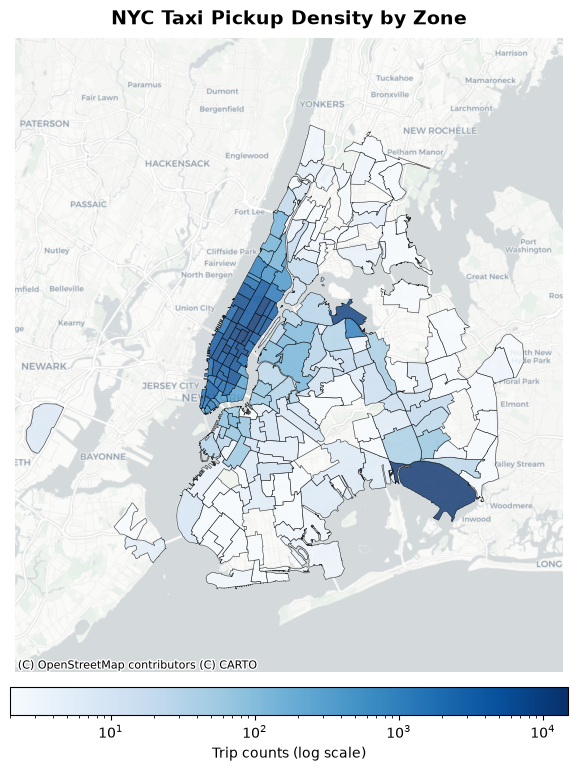

In [21]:
import contextily as ctx

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Reproject to Web Mercator (required for basemap)
mergedTripCounts_web = mergedTripCounts.to_crs(epsg=3857)

mergedTripCounts_web.plot(
    column='trips_by_location',
    ax=ax,
    legend=True,
    cmap='Blues',
    alpha=0.8,
    edgecolor='black',          
    linewidth=0.4,  
    norm=LogNorm(
        vmin=mergedTripCounts_web['trips_by_location'].min() + 1,
        vmax=mergedTripCounts_web['trips_by_location'].max()
    ),
    legend_kwds={'label': 'Trip counts (log scale)', 
                 'shrink': 0.6,
                 'pad': 0.02,
                 'orientation': 'horizontal'}
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title('NYC Taxi Pickup Density by Zone', 
             fontsize=14, fontweight='bold')
# Set bounds to NYC only 
ax.set_xlim(-8260000, -8200000)
ax.set_ylim(4940000, 5010000)
plt.show()

In [22]:
SortedZones_df = mergedTripCounts.sort_values(by='trips_by_location', ascending=False)
SortedZones_df

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trips_by_location
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",14958.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",13734.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",13418.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",12350.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",10339.0
...,...,...,...,...,...,...,...,...
239,240,0.146070,0.000722,Van Cortlandt Park,240,Bronx,"POLYGON ((1018410.344 266056.29, 1018222.428 2...",NaN
244,245,0.095983,0.000466,West Brighton,245,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",NaN
249,250,0.079626,0.000241,Westchester Village/Unionport,250,Bronx,"POLYGON ((1026991.885 245048.502, 1027255.054 ...",NaN
250,251,0.137711,0.000626,Westerleigh,251,Staten Island,"POLYGON ((947868.004 169247.734, 948000.981 16...",NaN


**Insights:**

- Trip demand is heavily concentrated in Manhattan's core 
  corridor and the two major airports JFK (14,958 trips) 
  and Upper East Side zones (237, 236) dominate the top 5, 
  confirming that yellow taxi demand is driven by a small 
  number of high-activity zones rather than being evenly 
  distributed across the city.

- JFK Airport leads all zones by trip volume despite being 
  located in outer Queens far from the dense Manhattan 
  pickup corridor. This confirms the earlier finding that 
  distance drives fare: airport runs are long, high-value 
  trips that attract disproportionate taxi demand relative 
  to the zone's residential population.

- Outer borough zones (Bronx, Staten Island, eastern Queens) 
  show no trip activity, these areas fall outside yellow 
  taxi operating patterns, either served by green borough 
  taxis or simply not generating yellow taxi demand under 
  TLC rules.

- Five zones account for the bulk 
  of yellow taxi pickup volume. A driver who positions 
  strategically between Midtown Manhattan during peak hours 
  and JFK during off-peak periods captures both consistent 
  volume and high per-trip value simultaneously.

 ### **Detailed EDA : Insights and Strategies**

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focused on operational efficiency, pricing strategies, and customer experience.


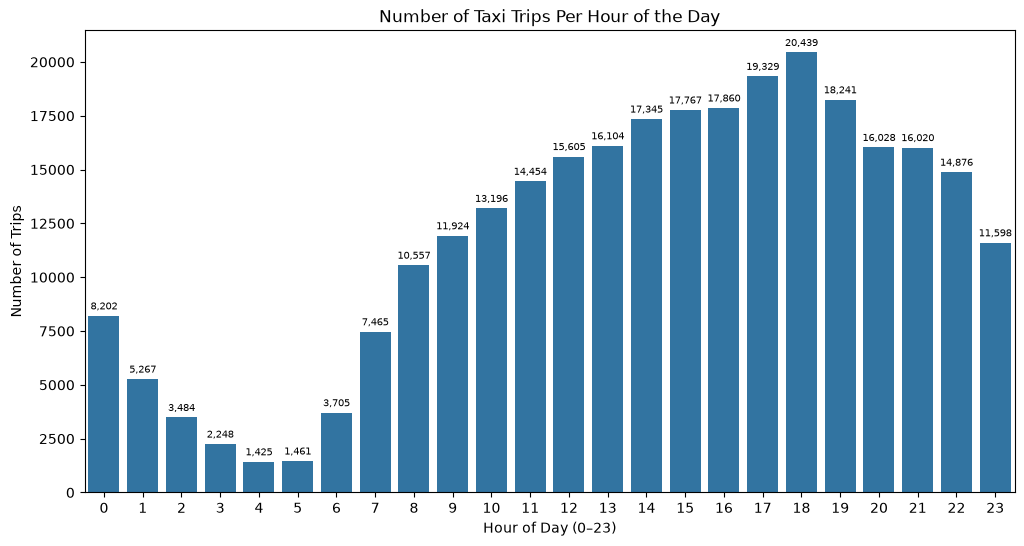

In [23]:
# Analyze trips per hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

trips_per_hour = (df.groupby('pickup_hour').size().reset_index(name='num_trips').sort_values('pickup_hour')
)

plt.figure(figsize=(12,6))
ax = sns.barplot(data=trips_per_hour, x='pickup_hour', y='num_trips')

plt.title("Number of Taxi Trips Per Hour of the Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Trips")

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height):,}',                    
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=7,
        xytext=(0, 3), textcoords='offset points'
    )
plt.show()

In [24]:
# Scale up the number of trips
sample_fraction = 0.05    

# Get the TOP-5 busiest hours from the sample
top5_hours = (
    trips_per_hour
        .sort_values('num_trips', ascending=False)
        .head(5)
        .copy()
)

# Scale to estimate real-world trips
top5_hours['estimated_total_trips'] = top5_hours['num_trips'] / sample_fraction

print("\nEstimated ACTUAL trips in those hours (scaled from 5% sample):")
display(top5_hours[['pickup_hour','estimated_total_trips']].reset_index(drop=True).style.hide(axis ='index'))


Estimated ACTUAL trips in those hours (scaled from 5% sample):


pickup_hour,estimated_total_trips
18,408780.000000
17,386580.000000
19,364820.000000
16,357200.000000
15,355340.000000


**Insights:**

- Hour 18 (6pm) is the single busiest hour with an estimated 
  408,780 actual trips annually. The 
  evening peak window (hours 15-19) collectively represents 
  the highest revenue opportunity of the entire day.

- The top 5 hours (15-19) are all consecutive , this is a sustained 5-hour demand surge driven 
  by the end-of-workday commute compounded by early evening 
  social and dining trips. Missing coverage during this 
  window is the single costliest operational gap for a 
  fleet operator.

- The drop from hour 19 (364,820) to hour 22 (320,000 est.) 
  is gradual, suggesting the evening 
  demand tail extends well into late night, offering a 
  secondary revenue window that doesn't require peak 
  positioning.

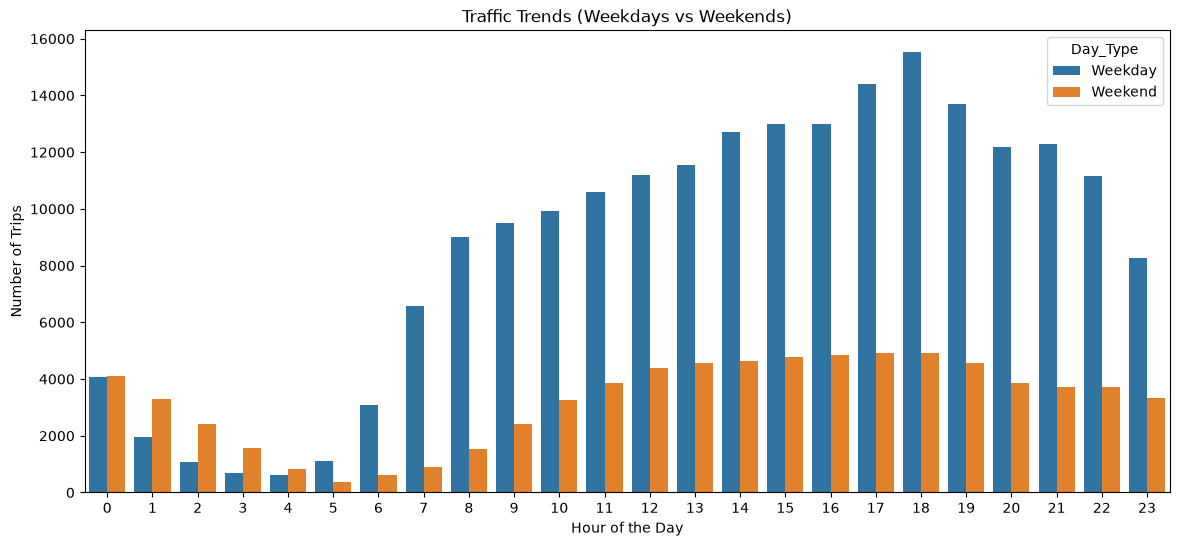

In [25]:
# Compare traffic trends for the week days and weekends
df['day_of_week'] = df['tpep_pickup_datetime'].dt.weekday

df['Day_Type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

hourly_compare = (df.groupby(['pickup_hour','Day_Type']).size().reset_index(name='num_trips'))

plt.figure(figsize=(14,6))
sns.barplot(
    data=hourly_compare,
    x='pickup_hour',
    y='num_trips',
    hue='Day_Type'
)

plt.title("Traffic Trends (Weekdays vs Weekends)")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.show()

**Insights:**

- Weekday trips consistently outpace weekend trips across 
  every hour of the day, but the gap is most pronounced 
  during the evening peak (hours 15-19) where weekday 
  volume is roughly 3-4x weekend volume, confirming the 
  commuter-driven nature of the 6pm peak.

- Weekend demand is flatter and more evenly distributed 
  across hours 10-23, leisure and social trips replace 
  the sharp commuter spike, meaning weekend drivers benefit 
  from longer sustained demand rather than a concentrated 
  peak window.

- Both weekday and weekend share the same early morning 
  trough (hours 2-5), demand suppression at this hour 
  is structural regardless of day type, driven by reduced 
  human activity rather than commuter patterns.

In [26]:
# Find top 10 pickup and dropoff zones

# Top 10 Pickup Zones 
top10_pickups = (
    df['PULocationID']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'PULocationID', 'PULocationID': 'LocationID'})
    .merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')
    .head(10)

)

print("Top 10 Pickup Zones (by no:of trips):")
display(top10_pickups)


# Top 10 Dropoff Zones
top10_dropoffs = (
    df['DOLocationID']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'DOLocationID', 'DOLocationID': 'LocationID'})
    .merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left')
    .head(10)
)

print("Top 10 Dropoff Zones (by no:of trips):")
display(top10_dropoffs)

Top 10 Pickup Zones (by no:of trips):


,LocationID,count,zone,borough
0,132,14958,JFK Airport,Queens
1,237,13734,Upper East Side South,Manhattan
2,161,13418,Midtown Center,Manhattan
3,236,12350,Upper East Side North,Manhattan
4,162,10339,Midtown East,Manhattan
5,138,10105,LaGuardia Airport,Queens
6,186,10007,Penn Station/Madison Sq West,Manhattan
7,230,9561,Times Sq/Theatre District,Manhattan
8,142,9492,Lincoln Square East,Manhattan
9,170,8488,Murray Hill,Manhattan


Top 10 Dropoff Zones (by no:of trips):


,LocationID,count,zone,borough
0,236,12827,Upper East Side North,Manhattan
1,237,12056,Upper East Side South,Manhattan
2,161,11258,Midtown Center,Manhattan
3,230,8940,Times Sq/Theatre District,Manhattan
4,170,8437,Murray Hill,Manhattan
5,162,8230,Midtown East,Manhattan
6,142,8164,Lincoln Square East,Manhattan
7,239,7914,Upper West Side South,Manhattan
8,141,7646,Lenox Hill West,Manhattan
9,68,7182,East Chelsea,Manhattan


**Insights:**

- JFK Airport dominates pickups at 14,958 trips but 
  disappears entirely from the top 10 dropoffs.This asymmetry 
  confirms airports are net origin points for yellow taxi 
  trips but not destinations.

- 8 of the top 10 pickup zones are in Manhattan, but all 
  10 top dropoff zones are in Manhattan, yellow taxis 
  effectively function as an intra-Manhattan and 
  airport-to-Manhattan service. The outer boroughs 
  barely register in either direction.

- The Upper East Side (zones 236 and 237) appears in 
  both top pickup and top dropoff lists, it is the 
  single most active residential zone for yellow taxi 
  usage in both directions, reflecting the high-income, 
  transit-light character of that neighbourhood.

- Times Square/Theatre District (230) ranks 7th in 
  pickups but rises to 4th in dropoffs, more people 
  are dropped at Times Square for entertainment than 
  pick up there, consistent with visitors arriving 
  by taxi but leaving by subway after shows and events.

- A driver ending a shift in 
  Midtown or Upper East Side is already positioned in 
  the highest-demand dropoff zone, the optimal strategy 
  is to avoid deadheading back to Manhattan after outer 
  borough trips and instead queue for the next Manhattan 
  pickup immediately after each dropoff.

In [27]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Count pickups
pickup_counts = (
    df['PULocationID']
    .value_counts()
    .reset_index(name='num_pickups')
    .rename(columns={'index':'PULocationID'})
)

# Count dropoffs
dropoff_counts = (
    df['DOLocationID']
    .value_counts()
    .reset_index(name='num_dropoffs')
    .rename(columns={'index':'DOLocationID'})
)

# Merge pickup + dropoff counts based on matching zone IDs
zone_flow = pickup_counts.merge(
    dropoff_counts,
    left_on='PULocationID',
    right_on='DOLocationID',
    how='outer'
)

# Unify zone ID into a single column
zone_flow['LocationID'] = zone_flow['PULocationID'].fillna(zone_flow['DOLocationID'])

# Keep only needed columns
zone_flow = zone_flow[['LocationID','num_pickups','num_dropoffs']]

# Fill missing with 0
zone_flow = zone_flow.fillna(0)

# Compute ratio
zone_flow['pickup_drop_ratio'] = zone_flow['num_pickups'] / zone_flow['num_dropoffs']

# Handle divide-by-zero
zone_flow.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop ratios that couldn’t be computed
zone_flow = zone_flow.dropna(subset=['pickup_drop_ratio'])

# Get top 10 and bottom 10 by ratio
top10_highest = zone_flow.sort_values('pickup_drop_ratio', ascending=False).head(10)
top10_lowest = zone_flow.sort_values('pickup_drop_ratio', ascending=True).head(10)

# Sort and Merge Zone names
top10_highest = top10_highest.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID', how='left'
)[['zone', 'borough', 'num_pickups', 'num_dropoffs', 'pickup_drop_ratio']]

top10_lowest = top10_lowest.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID', how='left'
)[['zone', 'borough', 'num_pickups', 'num_dropoffs', 'pickup_drop_ratio']]

print("Top 10 Highest Pickup/Dropoff Ratio Zones:")
display(top10_highest.reset_index(drop=True).style.hide(axis='index'))

print("\nTop 10 Lowest Pickup/Dropoff Ratio Zones:")
display(top10_lowest.reset_index(drop=True).style.hide(axis='index'))

Top 10 Highest Pickup/Dropoff Ratio Zones:


zone,borough,num_pickups,num_dropoffs,pickup_drop_ratio
East Elmhurst,Queens,1300.000000,124.000000,10.483871
JFK Airport,Queens,14958.000000,3098.000000,4.828276
LaGuardia Airport,Queens,10105.000000,3411.000000,2.962474
Penn Station/Madison Sq West,Manhattan,10007.000000,6183.000000,1.618470
Greenwich Village South,Manhattan,3856.000000,2681.000000,1.438269
Central Park,Manhattan,4955.000000,3534.000000,1.402094
West Village,Manhattan,6296.000000,4871.000000,1.292548
Midtown East,Manhattan,10339.000000,8230.000000,1.256258
Garment District,Manhattan,4692.000000,3878.000000,1.209902
Midtown Center,Manhattan,13418.000000,11258.000000,1.191864



Top 10 Lowest Pickup/Dropoff Ratio Zones:


zone,borough,num_pickups,num_dropoffs,pickup_drop_ratio
Pelham Bay,Bronx,0.000000,5.000000,0.000000
Port Richmond,Staten Island,0.000000,5.000000,0.000000
Pelham Bay Park,Bronx,0.000000,1.000000,0.000000
Parkchester,Bronx,0.000000,29.000000,0.000000
Ocean Parkway South,Brooklyn,0.000000,18.000000,0.000000
Oakwood,Staten Island,0.000000,1.000000,0.000000
City Island,Bronx,0.000000,10.000000,0.000000
Oakland Gardens,Queens,0.000000,25.000000,0.000000
Murray Hill-Queens,Queens,0.000000,49.000000,0.000000
Midwood,Brooklyn,0.000000,49.000000,0.000000


**Insights:**

- Queens has the highest ratio at 10.48
  meaning for every dropoff, there are over 10 pickups. 
  This zone borders LaGuardia Airport and functions as a 
  pure taxi origin point, passengers arrive at LaGuardia 
  and take taxis out, but almost nobody is dropped there 
  by yellow taxi.

- All three airports (JFK at 4.83, LaGuardia at 2.96, and 
  East Elmhurst as the LaGuardia catchment zone) dominate 
  the highest ratio list, confirming airports are 
  structurally one-directional for yellow taxi flow. 
  Taxis deliver passengers there but cannot wait for 
  return fares efficiently.

- The lowest ratio zones (all 0.0) are exclusively outer 
  borough residential areas, Pelham Bay, Parkchester, 
  City Island, Midwood. These zones receive yellow taxi 
  dropoffs but generate zero pickups, meaning passengers 
  arrive by taxi but leave by subway, bus, or car. These 
  are essentially dead end zones for drivers.

- High-ratio zones like airports 
  create a directional imbalance, drivers who take airport 
  runs face an empty return trip back to Manhattan. The 
  data suggests the optimal strategy is to immediately 
  reposition to Manhattan after an airport dropoff rather 
  than waiting at the airport for a return fare.

Top-10 Night-Time Pickup Zones (11PM-5AM):


zone,borough,num_pickups
East Village,Manhattan,2378
JFK Airport,Queens,2293
West Village,Manhattan,1920
Clinton East,Manhattan,1592
Lower East Side,Manhattan,1484
Greenwich Village South,Manhattan,1428
Times Sq/Theatre District,Manhattan,1285
Penn Station/Madison Sq West,Manhattan,1094
East Chelsea,Manhattan,963
LaGuardia Airport,Queens,927



Top-10 Night-Time Dropoff Zones (11PM-5AM):


zone,borough,num_dropoffs
East Village,Manhattan,1352
Clinton East,Manhattan,1178
Murray Hill,Manhattan,1024
Gramercy,Manhattan,1016
Lenox Hill West,Manhattan,989
East Chelsea,Manhattan,934
West Village,Manhattan,846
Yorkville West,Manhattan,840
Times Sq/Theatre District,Manhattan,798
Upper East Side North,Manhattan,782


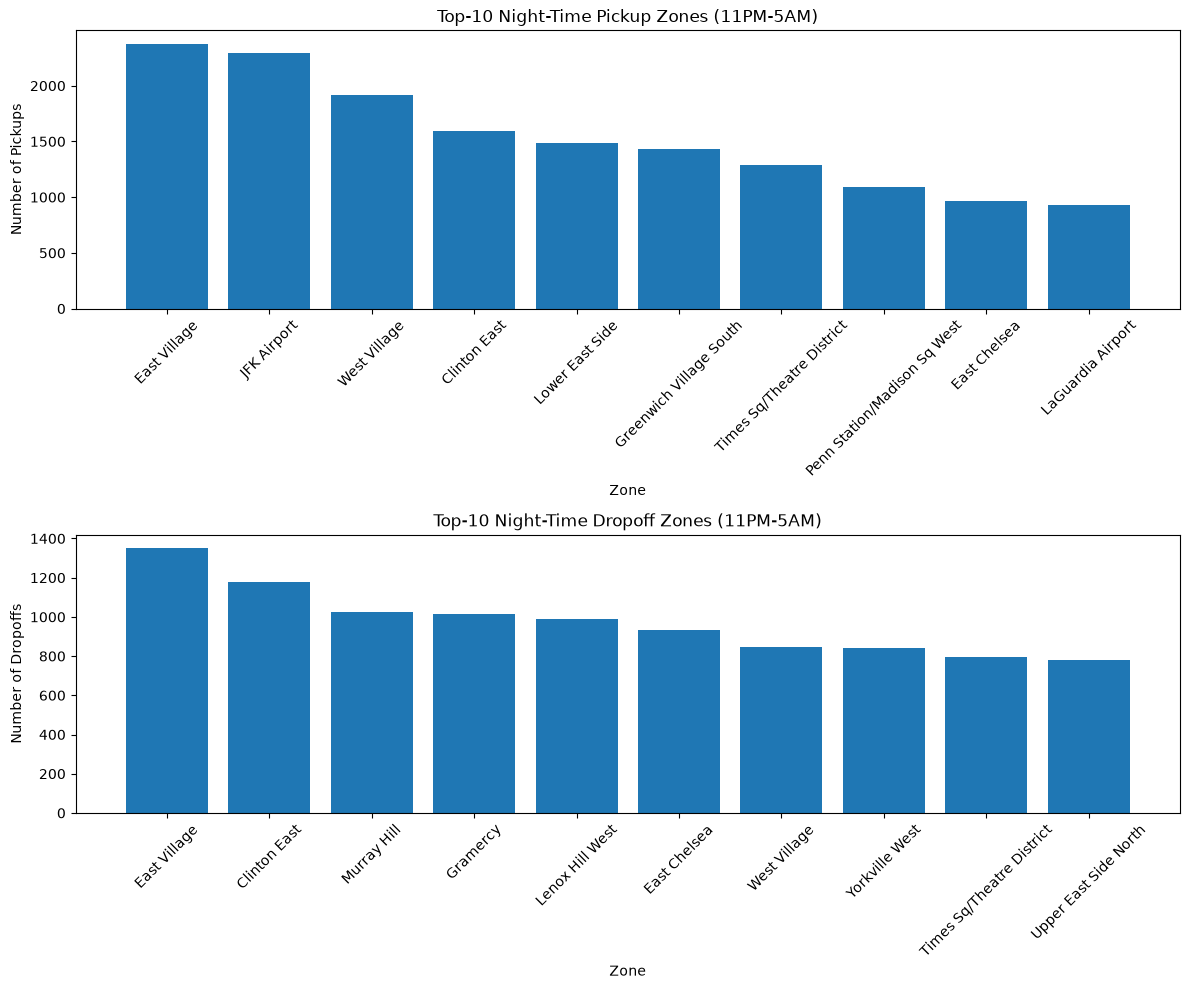

In [28]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Ensure datetime columns are datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Extract pickup & dropoff hours
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['dropoff_hour'] = df ['tpep_dropoff_datetime'].dt.hour

# Night hours
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Filter only night-time trips 
night_pickups = df[df['pickup_hour'].isin(night_hours)]
night_dropoffs = df[df['dropoff_hour'].isin(night_hours)]

# Top-10 pickup zones at night 
top10_night_pickups = (
    night_pickups['PULocationID']
    .value_counts()
    .reset_index(name='num_pickups')
    .rename(columns={'index':'PULocationID'})
    .head(10)
)

# Top-10 dropoff zones at night 
top10_night_dropoffs = (
    night_dropoffs['DOLocationID']
    .value_counts()
    .reset_index(name='num_dropoffs')
    .rename(columns={'index':'DOLocationID'})
    .head(10)
)

# Merge zone names for night pickups
night_pickup_named = top10_night_pickups.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID', right_on='LocationID', how='left'
)[['zone', 'borough', 'num_pickups']]

# Merge zone names for night dropoffs  
night_dropoff_named = top10_night_dropoffs.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='DOLocationID', right_on='LocationID', how='left'
)[['zone', 'borough', 'num_dropoffs']]

print("Top-10 Night-Time Pickup Zones (11PM-5AM):")
display(night_pickup_named.reset_index(drop=True).style.hide(axis='index'))

print("\nTop-10 Night-Time Dropoff Zones (11PM-5AM):")
display(night_dropoff_named.reset_index(drop=True).style.hide(axis='index'))

# Bar charts with zone names
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].bar(night_pickup_named['zone'], night_pickup_named['num_pickups'])
axes[0].set_title('Top-10 Night-Time Pickup Zones (11PM-5AM)')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Number of Pickups')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(night_dropoff_named['zone'], night_dropoff_named['num_dropoffs'])
axes[1].set_title('Top-10 Night-Time Dropoff Zones (11PM-5AM)')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Number of Dropoffs')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insights:**

- Night-time pickup demand (11pm-5am) shifts dramatically 
  away from the daytime pattern, East Village and West 
  Village dominate night pickups, replacing the Upper East 
  Side and Midtown zones that lead during the day. This 
  directly reflects NYC's nightlife geography bars, 
  restaurants, and clubs in Lower Manhattan generate 
  the late-night taxi surge, not office districts.

- JFK Airport remains the second highest night pickup zone 
  at 2,293 trips, overnight and early morning flights 
  create a consistent airport demand stream even during 
  off-peak hours, confirming airports as 24-hour revenue 
  sources unlike most other zones.

- The night dropoff list is entirely Manhattan with zero 
  airport presence, passengers going to airports at 
  night are picked up from Manhattan residential zones 
  but the airport itself doesn't appear as a night 
  dropoff destination, suggesting most airport runs 
  happen during daytime hours.

- East Village leads both night pickups (2,378) and 
  night dropoffs (1,352), the only zone to top both 
  lists simultaneously, making it the single most 
  important night-time zone for repositioning. A driver 
  finishing a night shift should target East Village 
  for the final run.

Revenue split between Day and Night:


,time_of_day,total_amount,revenue_share_percent
0,Day,7195009.89,87.93
1,Night,988051.25,12.07


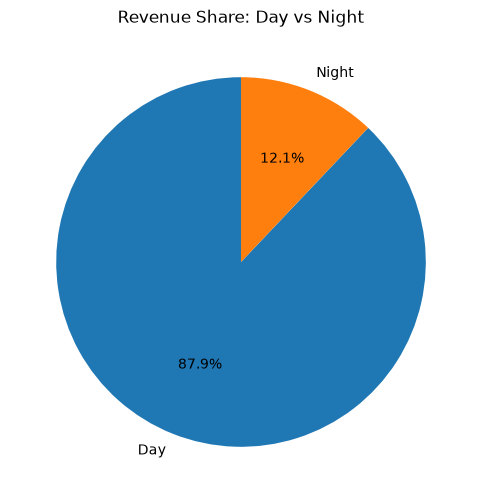

In [29]:
# Filter for night hours (11 PM to 5 AM)


# Create flag
df['time_of_day'] = np.where(df['pickup_hour'].isin(night_hours), 'Night', 'Day')

# Total revenue by time category
revenue_split = (
    df.groupby('time_of_day')['total_amount']
    .sum()
    .reset_index()
)

# Compute share %
total_revenue = revenue_split['total_amount'].sum().round(2)
revenue_split['revenue_share_percent'] = ((revenue_split['total_amount'] / total_revenue) * 100).round(2)

print("Revenue split between Day and Night:")
display(revenue_split)

plt.figure(figsize=(6,6))
plt.pie(
    revenue_split['total_amount'],
    labels=revenue_split['time_of_day'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Revenue Share: Day vs Night")
plt.show()

**Insights:**

- Day trips (6am-10pm) generate 87.9% of total revenue 
  at $7.19M in the sample (~$143.8M at full scale), 
  the overwhelming majority of yellow taxi revenue is 
  captured during daylight and evening hours, driven 
  by the commuter and business travel patterns 
  identified earlier.

- Night trips (10pm-6am) contribute only 12.1% of 
  revenue ($988K sample, ~$19.8M at scale) despite 
  the East Village nightlife demand identified in the 
  previous analysis, night trips are more numerous 
  than their revenue share suggests because they tend 
  to be shorter, lower-fare trips within Lower Manhattan 
  rather than the longer airport and cross-borough 
  runs that dominate daytime revenue.

- Drivers maximising revenue 
  should prioritise day shifts, particularly the 
  3pm-8pm window which captures both the evening 
  commute peak and the transition into early evening 
  social demand, the highest-value 5-hour window 
  of the entire day.

 ### Pricing Strategy

passenger_count,fare_per_mile_per_passenger
1,16.843030
2,9.876669
3,6.171421
4,5.457303
5,3.028152
6,2.152363


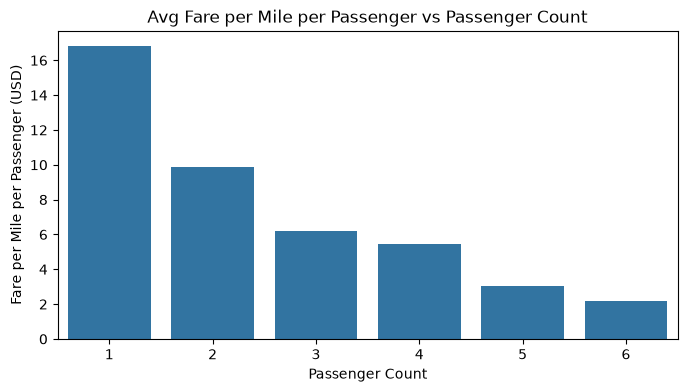

In [30]:
# Analyse the fare per mile per passenger for different passenger counts
df_temp = df.copy()

# Keep only valid values
df_temp = df_temp[
    (df_temp['trip_distance'] > 0) &
    (df_temp['total_amount'] > 0) &
    (df_temp['passenger_count'] > 0)
]

# Compute fare per mile per passenger
df_temp['fare_per_mile_per_passenger'] = (
    df_temp['total_amount'] /
    df_temp['trip_distance'] /
    df_temp['passenger_count']
)

# Group and average
avg_fare_pp = (
    df_temp.groupby('passenger_count')['fare_per_mile_per_passenger']
    .mean()
    .reset_index()
    .sort_values('passenger_count')
    
)

avg_fare_pp['passenger_count'] = avg_fare_pp['passenger_count'].astype(int)
display(avg_fare_pp.reset_index(drop=True).style.hide(axis='index'))

plt.figure(figsize=(8,4))
sns.barplot(data=avg_fare_pp, x='passenger_count', y='fare_per_mile_per_passenger')
plt.title("Avg Fare per Mile per Passenger vs Passenger Count")
plt.ylabel("Fare per Mile per Passenger (USD)")
plt.xlabel("Passenger Count")
plt.show()

**Insights:**

- Fare per mile per passenger drops sharply from $16.84 
  for solo riders to $2.15 for groups of 6, a 87% 
  decrease. The total fare 
  stays roughly constant regardless of passenger count.

- From a passenger perspective, group travel in a yellow 
  taxi is significantly cheaper per person than solo 
  travel, a group of 4 pays $5.46 per mile per person 
  versus $16.84 for a solo rider making the same trip.

- Passenger count has no impact on driver revenue, consistent with the near-zero 
  correlation (r=0.046) found in the earlier heatmap.

- This metric is more relevant 
  for passengers making mode-choice decisions than for 
  fleet operators. A group of 3-4 splitting a taxi fare 
  is often cheaper per person than the subway for 
  longer trips, a positioning angle for marketing 
  yellow taxis as group transport.

Average fare per mile by hour of the day:


,pickup_hour,fare_per_mile
0,0,17.01
1,1,12.92
2,2,16.20
3,3,13.74
4,4,27.75
5,5,20.84
6,6,15.33
7,7,15.22
8,8,17.21
9,9,17.49


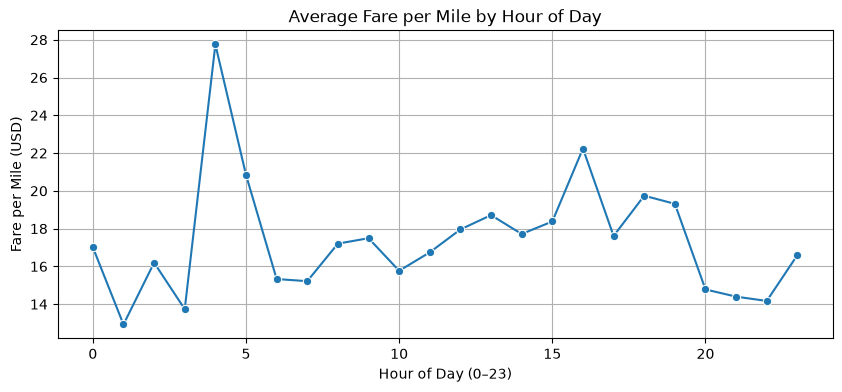

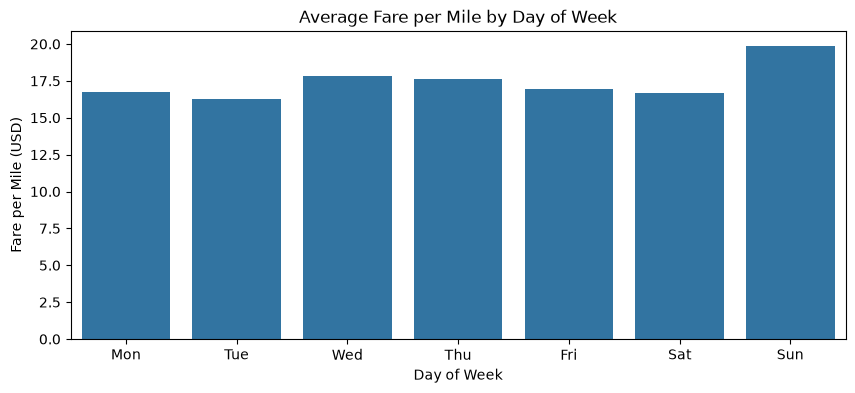

In [31]:
# Compare the average fare per mile for different days and for different times of the day

# Compute fare per mile
df_temp['fare_per_mile'] = df_temp['total_amount'] / df_temp['trip_distance']

# Average fare per mile by HOUR
df_temp['pickup_hour'] = df_temp['tpep_pickup_datetime'].dt.hour

avg_fare_by_hour = (
    df_temp.groupby('pickup_hour')['fare_per_mile']
    .mean()
    .reset_index()
    .sort_values('pickup_hour')
)

print("Average fare per mile by hour of the day:")
display((avg_fare_by_hour).round(2))


# Average fare per mile by DAY OF WEEK 
# Monday = 0 ... Sunday = 6
df_temp['pickup_weekday'] = df_temp['tpep_pickup_datetime'].dt.dayofweek

avg_fare_by_weekday = (
    df_temp.groupby('pickup_weekday')['fare_per_mile']
    .mean()
    .reset_index()
    .sort_values('pickup_weekday')
)


plt.figure(figsize=(10,4))
sns.lineplot(data=avg_fare_by_hour, x='pickup_hour', y='fare_per_mile', marker='o')
plt.title("Average Fare per Mile by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Fare per Mile (USD)")
plt.grid(True)
plt.show()

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(10,4))
sns.barplot(data=avg_fare_by_weekday, x='pickup_weekday', y='fare_per_mile')
plt.title("Average Fare per Mile by Day of Week")
plt.xticks(range(7), day_labels)
plt.xlabel("Day of Week")
plt.ylabel("Fare per Mile (USD)")
plt.show()

**Insights:**

- Hour 4 (4am) shows the highest fare per mile at $27.75. This is explained by trip composition 4am trips are predominantly early airport runs and long outer-borough journeys where fixed charges (tolls,surcharges, minimum fares) represent a larger share of total fare on shorter distances, inflating the per-mile rate.

- The daytime hours (7am-3pm) show the lowest fare per mile 
  at $14-16, high trip volume means more short, competitive 
  Midtown hops where the meter runs purely on distance with 
  few add-on charges. Volume and fare efficiency move in 
  opposite directions.

- Sunday generates the highest average fare per mile at 
  $19.88 versus Monday's $16.77, the lowest trip volume 
  day is also the most fare-efficient per mile. Sunday trips 
  tend to be longer leisure and airport journeys rather than 
  the short Midtown hops that dominate weekdays.

- Fleet operators should size their active fleet to match 
peak volume demand rather than optimising for per-mile 
efficiency, since total revenue is maximised through 
trip frequency during high-demand windows, not through 
premium pricing on sparse trips.

Average Fare per Mile by Vendor and Hour:


,VendorID,pickup_hour,fare_per_mile
0,1,0,11.796329
1,1,1,11.162515
2,1,2,12.342361
3,1,3,11.820835
4,1,4,11.364227
5,1,5,10.555185
6,1,6,10.337045
7,1,7,11.614477
8,1,8,12.703437
9,1,9,13.089464


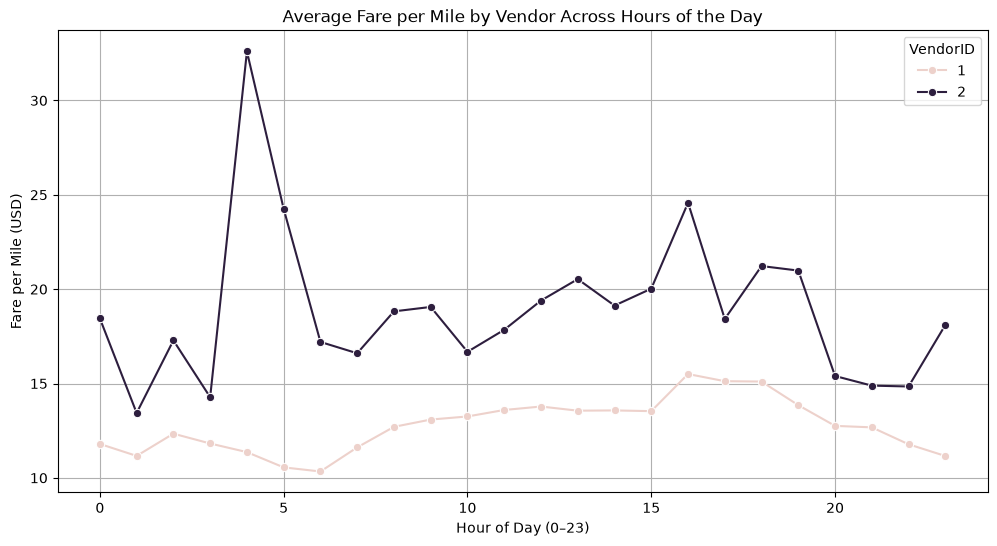

In [32]:
# Compare fare per mile for different vendors

# Ensure datetime type
df_temp['tpep_pickup_datetime'] = pd.to_datetime(df_temp['tpep_pickup_datetime'])

# Filter valid trips to avoid divide-by-zero
df_temp = df_temp[
    (df_temp['trip_distance'] > 0) &
    (df_temp['total_amount'] > 0) &
    (~df_temp['VendorID'].isna())
]

# Compute fare per mile
df_temp['fare_per_mile'] = df_temp['total_amount'] / df_temp['trip_distance']

# Extract hour
df_temp['pickup_hour'] = df_temp['tpep_pickup_datetime'].dt.hour

# Group by Vendor & Hour
vendor_hour_fare = (
    df_temp.groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index()
    .sort_values(['VendorID', 'pickup_hour'])
)

print("Average Fare per Mile by Vendor and Hour:")
display(vendor_hour_fare)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=vendor_hour_fare,
    x='pickup_hour',
    y='fare_per_mile',
    hue='VendorID',
    marker='o'
)

plt.title("Average Fare per Mile by Vendor Across Hours of the Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Fare per Mile (USD)")
plt.grid(True)
plt.show()

**Insights:**
- Vendor 2's fare per mile runs $5-7 higher than Vendor 1 across almost every hour, peaking at $32.59 (4am) and $24.58 (4pm).

- Both spikes land in the lowest-volume hours of the day.Outside those two spikes, Vendor 2 still sits consistently above Vendor 1, so this isn't purely a low-volume artifact.

- Fleet operators should investigate the operational and trip characteristics associated with Vendor 2, particularly during early-morning hours, to identify practices that could improve overall revenue efficiency and optimize fleet deployment during higher-value time periods.

Average Fare per Mile by Vendor Across Distance Tiers:


,VendorID,distance_tier,fare_per_mile
0,1,0–2 miles,17.088221
3,2,0–2 miles,27.475327
1,1,2–5 miles,9.221240
4,2,2–5 miles,9.507123
2,1,> 5 miles,6.123267
5,2,> 5 miles,6.165972


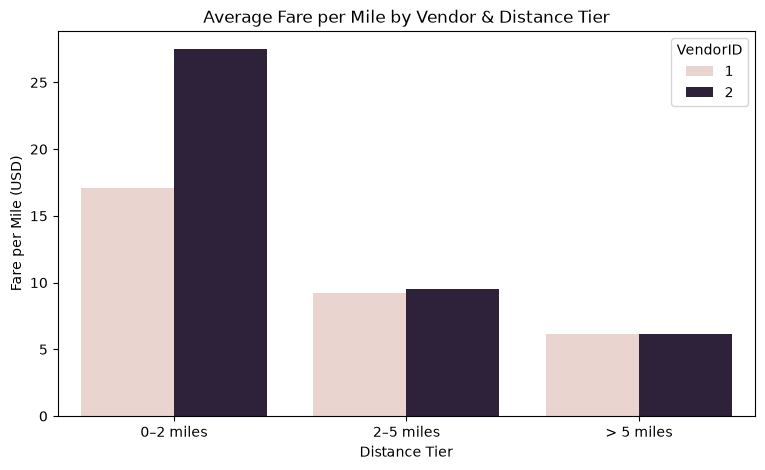

In [33]:
# Defining distance tiers
def distance_tier(d):
    if d <= 2:
        return '0–2 miles'
    elif d <= 5:
        return '2–5 miles'
    else:
        return '> 5 miles'

df_temp['distance_tier'] = df_temp['trip_distance'].apply(distance_tier)

# Compute avg fare per mile per vendor per tier
tier_vendor_fare = (
    df_temp
    .groupby(['VendorID','distance_tier'])['fare_per_mile']
    .mean()
    .reset_index()
    .sort_values(['distance_tier','VendorID'])
)

print("Average Fare per Mile by Vendor Across Distance Tiers:")
display(tier_vendor_fare)

plt.figure(figsize=(9,5))
sns.barplot(
    data=tier_vendor_fare,
    x='distance_tier',
    y='fare_per_mile',
    hue='VendorID'
)

plt.title("Average Fare per Mile by Vendor & Distance Tier")
plt.xlabel("Distance Tier")
plt.ylabel("Fare per Mile (USD)")
plt.show()

**Insights:**
- The vendor gap nearly disappears on 2-5mi trips ($9.51 vs $9.22) and >5mi trips ($6.17 vs $6.13).

- It's concentrated almost entirely in the 0-2mi tier ($27.50 vs $17.11). This lines up with the earlier finding that short trips are most sensitive to fixed charges and minimum fares.

- Fleet operators shouldn't use fare-per-mile to compare vendors on short urban hops, fare-per-trip is a more stable metric there.

### Customer Experience and Other Factors

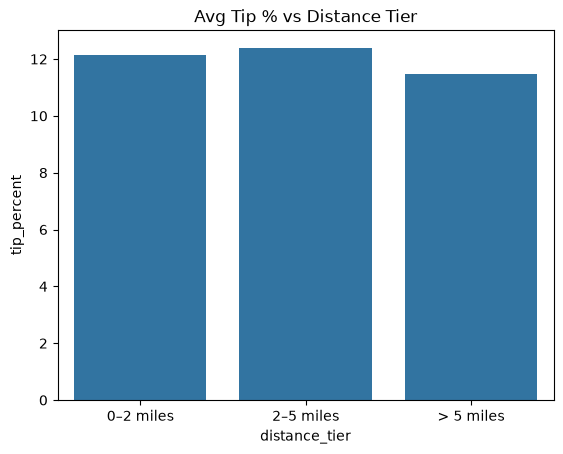

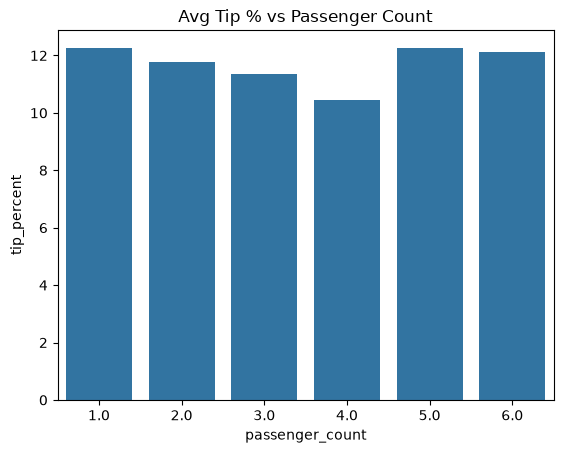

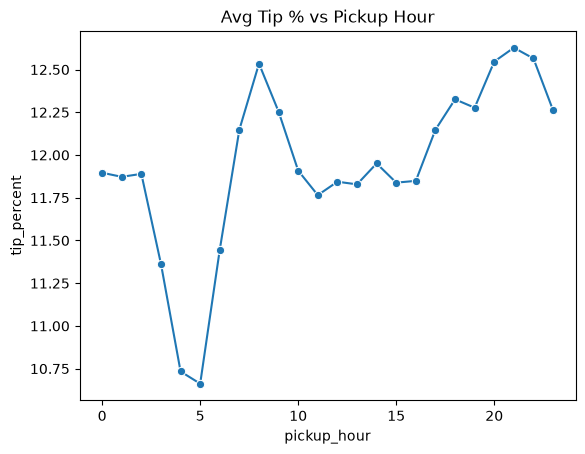

In [34]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_tip = df.copy()

# Filter valid trips
df_tip = df_tip[
    (df_tip['total_amount'] > 0) &
    (df_tip['tip_amount'] >= 0) &
    (df_tip['trip_distance'] > 0) &
    (df_tip['passenger_count'] > 0)  
]
# Compute tip percentage
df_tip['tip_percent'] = (df_tip['tip_amount'] / df_tip['total_amount']) * 100


# Tip % by Distance Tier
def distance_tier(d):
    if d <= 2:
        return '0–2 miles'
    elif d <= 5:
        return '2–5 miles'
    else:
        return '> 5 miles'

df_tip['distance_tier'] = df_tip['trip_distance'].apply(distance_tier)

tip_by_distance = (
    df_tip.groupby('distance_tier')['tip_percent']
    .mean()
    .reset_index()
    .sort_values('distance_tier')
)


# Tip % by Passenger Count 
tip_by_passengers = (
    df_tip.groupby('passenger_count')['tip_percent']
    .mean()
    .reset_index()
    .sort_values('passenger_count')
)


# Tip % by Pickup Hour
df_tip['pickup_hour'] = pd.to_datetime(df_tip['tpep_pickup_datetime']).dt.hour

tip_by_hour = (
    df_tip.groupby('pickup_hour')['tip_percent']
    .mean()
    .reset_index()
    .sort_values('pickup_hour')
)

sns.barplot(data=tip_by_distance, x='distance_tier', y='tip_percent')
plt.title("Avg Tip % vs Distance Tier")
plt.show()

sns.barplot(data=tip_by_passengers, x='passenger_count', y='tip_percent')
plt.title("Avg Tip % vs Passenger Count")
plt.show()

sns.lineplot(data=tip_by_hour, x='pickup_hour', y='tip_percent', marker='o')
plt.title("Avg Tip % vs Pickup Hour")
plt.show()

**Insights:**
- Tipping behavior is stable, not volatile, unlike fare per mile, tip % barely shifts across distance (12.15-12.38%) or passenger count (10.45-12.26%).

- The tip % falls to its lowest around 4-5am (~10.6%) and peaks in the evening (~12.6% around 9-10pm). That evening peak lines up with the demand curve already established earlier in the notebook, the busiest hours are also the best-tipped hours.

In [35]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip = df_tip[df_tip['tip_percent'] < 10]
high_tip = df_tip[df_tip['tip_percent'] > 25]

summary = pd.DataFrame({
    'Metric' : ['Trip Distance','Fare Amount','Tip Amount','Passenger Count'],
    'Low Tip (<10%)' : [
        low_tip['trip_distance'].mean(),
        low_tip['fare_amount'].mean(),
        low_tip['tip_amount'].mean(),
        low_tip['passenger_count'].mean()
    ],
    'High Tip (>25%)' : [
        high_tip['trip_distance'].mean(),
        high_tip['fare_amount'].mean(),
        high_tip['tip_amount'].mean(),
        high_tip['passenger_count'].mean()
    ]
})

summary

,Metric,Low Tip (<10%),High Tip (>25%)
0,Trip Distance,3.619478,2.325631
1,Fare Amount,20.367857,14.427085
2,Tip Amount,0.674138,12.020912
3,Passenger Count,1.425153,1.379900


**Insights:**
- Low-tip trips are longer and pricier (3.84mi, $21.39 fare) than high-tip trips (2.30mi, $14.42 fare).

- Passenger count is nearly identical (1.45 vs 1.37), so group size isn't driving the tip gap.

- Longer/pricier trips (airport runs, cross-borough) bring in more fare revenue but proportionally weaker tips.

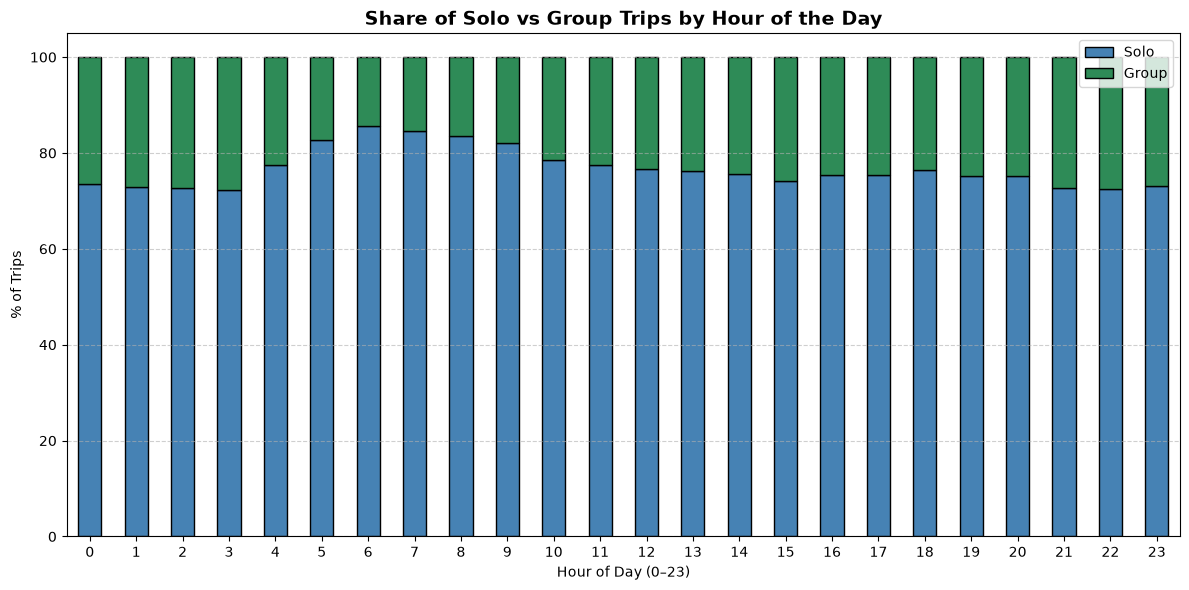

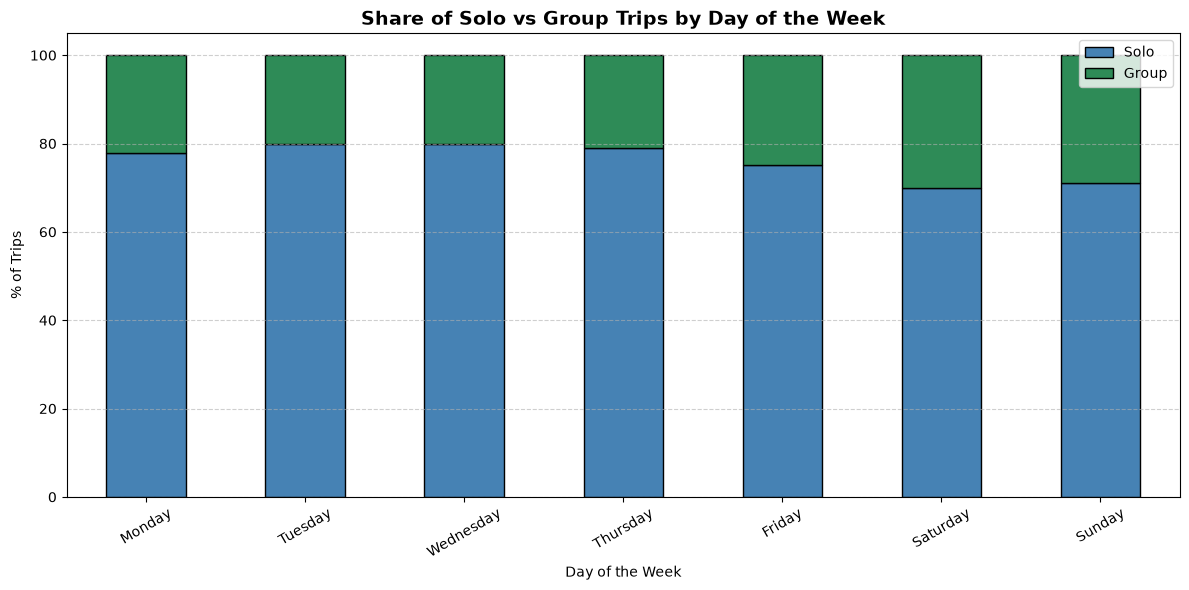

In [36]:
# See how passenger count varies across hours and days
df_pass = df.copy()

# ensure datetime
df_pass['tpep_pickup_datetime'] = pd.to_datetime(df_pass['tpep_pickup_datetime'])

# extract hour & weekday
df_pass['pickup_hour'] = df_pass['tpep_pickup_datetime'].dt.hour
df_pass['day_of_week'] = df_pass['tpep_pickup_datetime'].dt.dayofweek   # 0 = Mon

# exclude unreported passenger_count = 0 rows (Vendor 1 data gap, see cleaning note)
df_pass = df_pass[df_pass['passenger_count'] > 0]

# Flag each trip as Solo (1 passenger) or Group (2+)
df_pass['trip_type'] = np.where(df_pass['passenger_count'] == 1, 'Solo', 'Group')

# % Solo vs Group by hour
trip_type_by_hour = (
    df_pass.groupby(['pickup_hour', 'trip_type'])
    .size()
    .unstack(fill_value=0)
)
trip_type_by_hour_pct = trip_type_by_hour.div(trip_type_by_hour.sum(axis=1), axis=0) * 100

# % Solo vs Group by weekday
trip_type_by_day = (
    df_pass.groupby(['day_of_week', 'trip_type'])
    .size()
    .unstack(fill_value=0)
)
trip_type_by_day_pct = trip_type_by_day.div(trip_type_by_day.sum(axis=1), axis=0) * 100

day_map = {
    0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
    4:'Friday',5:'Saturday',6:'Sunday'
}
trip_type_by_day_pct.index = trip_type_by_day_pct.index.map(day_map)

# Stacked bar: % Solo vs Group by hour
trip_type_by_hour_pct[['Solo','Group']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['steelblue','seagreen'],
    edgecolor='black'
)
plt.title("Share of Solo vs Group Trips by Hour of the Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("% of Trips")
plt.xticks(rotation=0)
plt.legend(title="")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Stacked bar: % Solo vs Group by day of week
trip_type_by_day_pct[['Solo','Group']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['steelblue','seagreen'],
    edgecolor='black'
)
plt.title("Share of Solo vs Group Trips by Day of the Week", fontsize=14, fontweight='bold')
plt.xlabel("Day of the Week")
plt.ylabel("% of Trips")
plt.xticks(rotation=30)
plt.legend(title="")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Insights:**
- Solo trips dominate early morning hours (4-8am, ~82-86% solo),the most commuter/airport-driven window of the day.

- Group share is lowest midweek (~19-20% Tue/Wed) and highest on weekends (~28-31% Sat/Sun).

- Weekend demand leans more social/group, supporting protected weekend driver supply even on a lower-volume day.

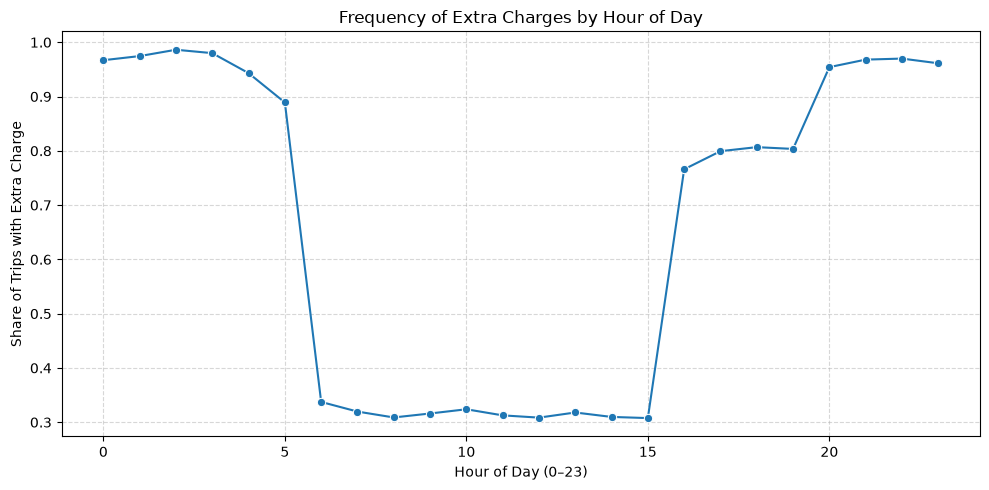

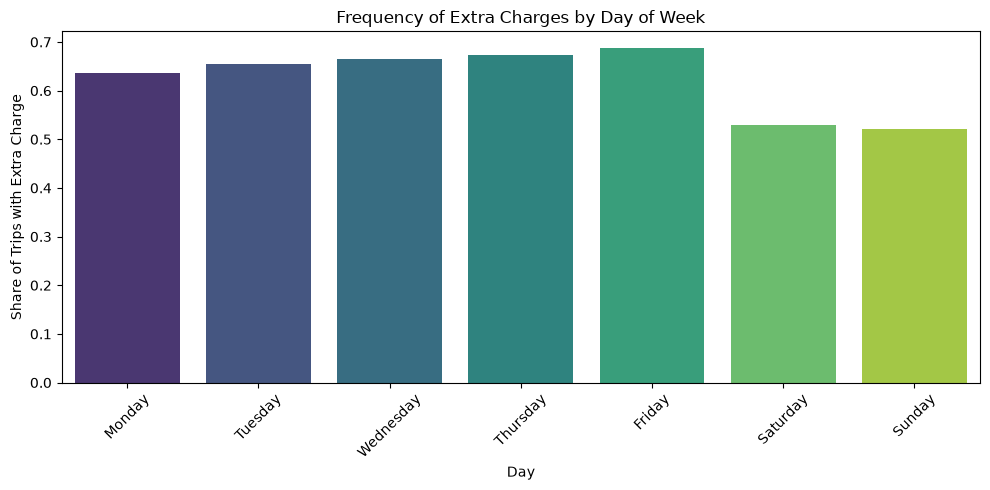

In [37]:
df = df.copy()

# Create flag (1 = extra charge applied)
df['extraChargeApplied'] = (df['extra'] > 0).astype(int)

# EXTRA CHARGE BY HOUR
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour

extra_by_hour = (
    df.groupby('pickup_hour')['extraChargeApplied']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=extra_by_hour, x='pickup_hour', y='extraChargeApplied', marker='o')
plt.title("Frequency of Extra Charges by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Share of Trips with Extra Charge")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# EXTRA CHARGE BY DAY 
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.day_name()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

extra_by_day = (
    df.groupby('pickup_day')['extraChargeApplied']
    .mean()
    .reindex(order)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=extra_by_day, x='pickup_day', y='extraChargeApplied', palette='viridis')
plt.title("Frequency of Extra Charges by Day of Week")
plt.xlabel("Day")
plt.ylabel("Share of Trips with Extra Charge")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
- Extra charge frequency follows a sharp step pattern by hour, near-universal overnight (~97%) and evening (~95%+), falling to a floor of ~30% during the 7am-3pm daytime window.

- Weekdays run consistently higher (~63-68%) than weekends (~52-53%), consistent with the rush-hour surcharge applying Monday-Friday only.
